In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random
import jax

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [4]:
training_dwarfs_sdss = pd.read_pickle('data/training_set_dwarfs.pkl')
training_giants_sdss = pd.read_pickle('data/training_set_giants.pkl')

test_results_giants = pd.read_csv("data/test_results_giants.csv")
test_results_dwarfs = pd.read_csv("data/test_results_dwarfs.csv")

training_sdss_all = pd.concat([training_giants_sdss, training_dwarfs_sdss], ignore_index=True)
test_results_all = pd.concat([test_results_giants, test_results_dwarfs], ignore_index=True)

In [5]:
test_results_all.head()

,source_id,teff_true,teff_pred,teff_residual,logg_true,logg_pred,logg_residual,fe_h_true,fe_h_pred,fe_h_residual,...,ca_h_residual,ce_h_true,ce_h_pred,ce_h_residual,m_h_atm_true,m_h_atm_pred,m_h_atm_residual,alpha_m_atm_true,alpha_m_atm_pred,alpha_m_atm_residual
0,4814060827262809472,4697.359,4887.882937,190.524051,2.108,2.608717,0.500717,-0.683,-0.489196,0.193804,...,-0.067144,-0.382,-0.627737,-0.245737,-0.661,-0.444129,0.216871,0.157,0.040855,-0.116145
1,4814063369883462528,4580.192,4492.523622,-87.668273,2.760,2.581317,-0.178683,-0.206,-0.396024,-0.190024,...,-0.085005,-0.103,-0.692984,-0.589984,-0.208,-0.327259,-0.119259,0.049,0.110109,0.061109
2,4850949781675383168,4464.195,4434.388193,-29.806632,2.503,2.538551,0.035551,-0.017,0.070337,0.087337,...,0.135508,-0.016,0.107411,0.123411,-0.004,0.072277,0.076277,-0.018,-0.020541,-0.002541
3,4853869023703311616,4691.655,4607.959326,-83.695460,2.527,2.377087,-0.149913,-0.751,-0.897604,-0.146604,...,-0.042691,-0.995,-1.877284,-0.882284,-0.717,-0.835239,-0.118239,0.191,0.225902,0.034902
4,4854682146911861888,4527.026,4678.626845,151.600966,2.956,3.277318,0.321318,0.234,0.250708,0.016708,...,0.014401,0.226,0.113571,-0.112429,0.258,0.274981,0.016981,-0.009,-0.060466,-0.051466


In [6]:
# need this to read gaia SNRs
gaia_df = pd.read_csv("data/gaia_IDs_and_colors.csv")
gaia_df.head()

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,rvs_spec_sig_to_noise,teff_gspphot,logg_gspphot,mh_gspphot,phot_g_mean_mag,phot_rp_mean_mag,phot_bp_mean_mag
0,1158184012071254400,224.580705,4.759718,NaN,NaN,NaN,19.736637,128.47984,NaN,NaN,NaN,9.909913,9.081639,10.632524
1,458111077340747776,39.056693,57.728070,2.801820,8.709150,-3.880525,-5.394361,196.07227,NaN,NaN,NaN,8.862565,8.760913,8.895749
2,458111798895251072,39.148392,57.720606,2.804736,8.891490,-3.863349,-0.544152,242.61273,NaN,NaN,NaN,8.447208,8.353966,8.475003
3,458182957914380032,38.653083,58.189299,0.605749,3.157653,-1.858103,-18.019020,172.87813,NaN,NaN,NaN,10.574236,9.153232,13.172504
4,458388188632487040,35.849756,56.854216,1.462591,1.811199,-5.075412,-8.475615,218.92624,NaN,NaN,NaN,8.528695,8.353546,8.600220


In [7]:
gaia_snr_df = gaia_df[['source_id', 'rvs_spec_sig_to_noise']]

# 3. Merge into the giants dataframe
test_results_all = test_results_all.merge(
    gaia_snr_df, 
    on='source_id', 
    how='left'
)

In [9]:
test_results_all.head()

,source_id,teff_true,teff_pred,teff_residual,logg_true,logg_pred,logg_residual,fe_h_true,fe_h_pred,fe_h_residual,...,ce_h_true,ce_h_pred,ce_h_residual,m_h_atm_true,m_h_atm_pred,m_h_atm_residual,alpha_m_atm_true,alpha_m_atm_pred,alpha_m_atm_residual,rvs_spec_sig_to_noise
0,4814060827262809472,4697.359,4887.882937,190.524051,2.108,2.608717,0.500717,-0.683,-0.489196,0.193804,...,-0.382,-0.627737,-0.245737,-0.661,-0.444129,0.216871,0.157,0.040855,-0.116145,168.70752
1,4814063369883462528,4580.192,4492.523622,-87.668273,2.760,2.581317,-0.178683,-0.206,-0.396024,-0.190024,...,-0.103,-0.692984,-0.589984,-0.208,-0.327259,-0.119259,0.049,0.110109,0.061109,147.13797
2,4850949781675383168,4464.195,4434.388193,-29.806632,2.503,2.538551,0.035551,-0.017,0.070337,0.087337,...,-0.016,0.107411,0.123411,-0.004,0.072277,0.076277,-0.018,-0.020541,-0.002541,182.02473
3,4853869023703311616,4691.655,4607.959326,-83.695460,2.527,2.377087,-0.149913,-0.751,-0.897604,-0.146604,...,-0.995,-1.877284,-0.882284,-0.717,-0.835239,-0.118239,0.191,0.225902,0.034902,218.68594
4,4854682146911861888,4527.026,4678.626845,151.600966,2.956,3.277318,0.321318,0.234,0.250708,0.016708,...,0.226,0.113571,-0.112429,0.258,0.274981,0.016981,-0.009,-0.060466,-0.051466,154.74080


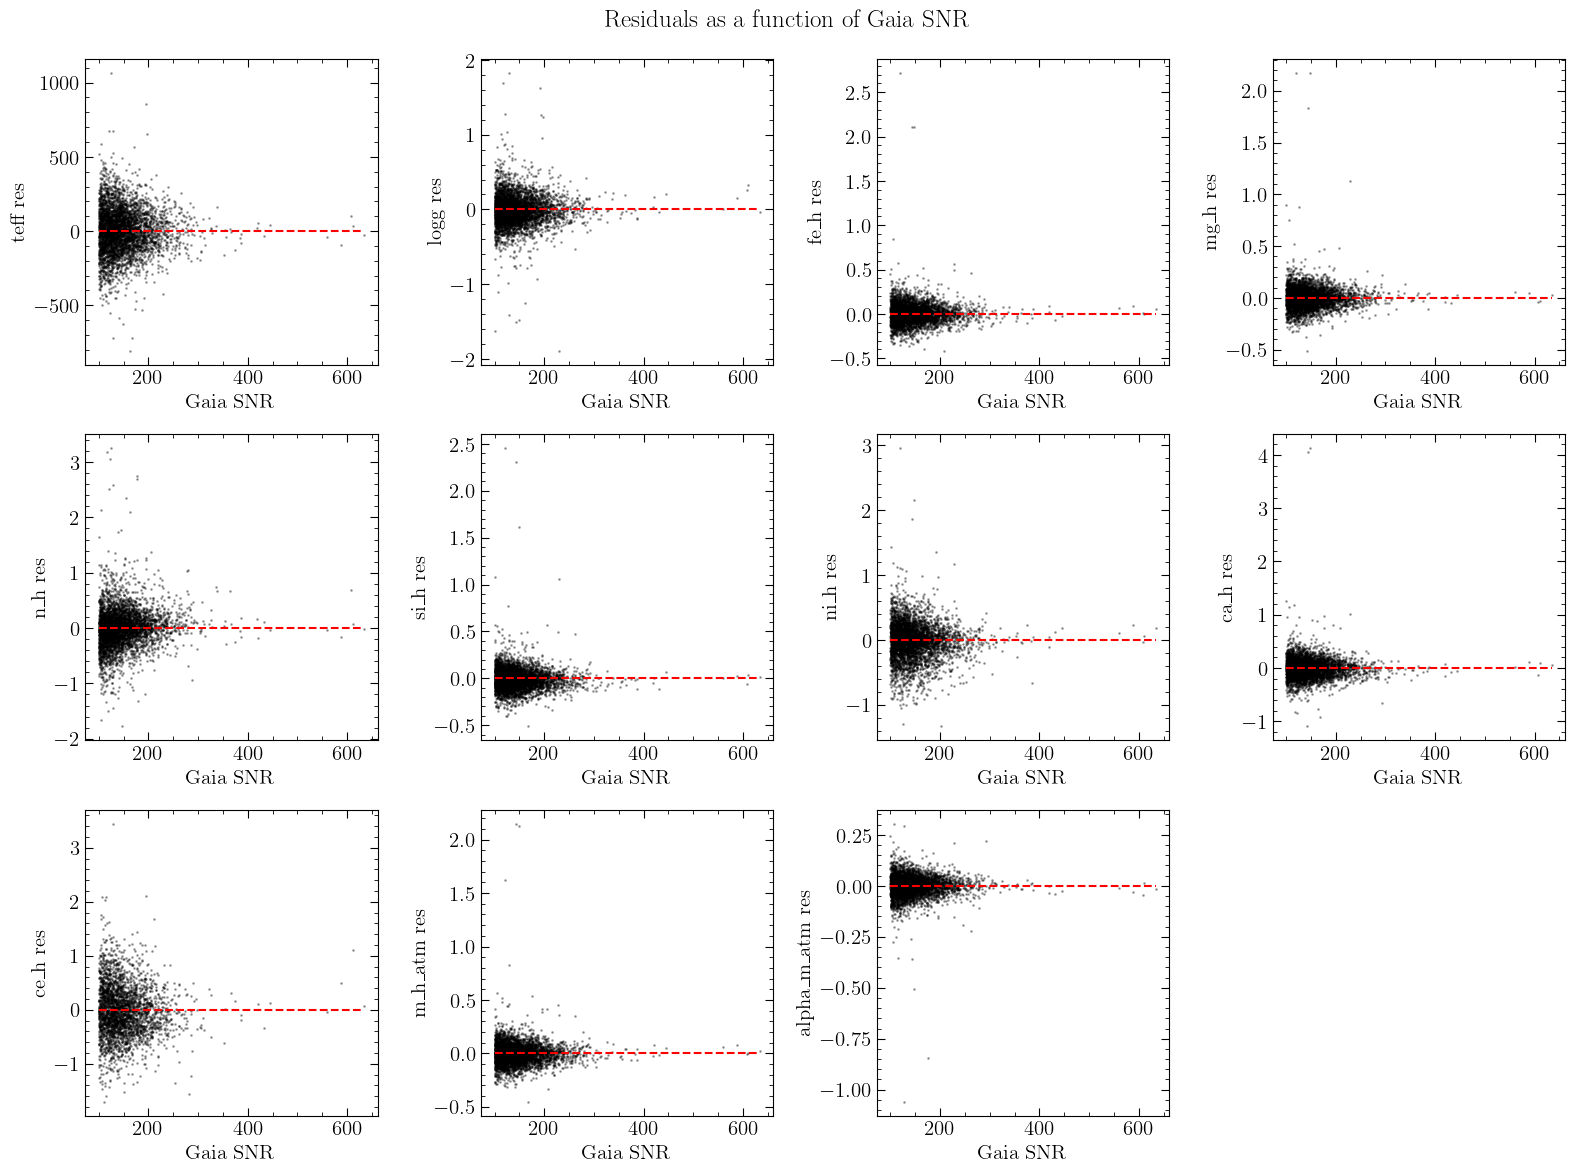

In [11]:
import matplotlib.pyplot as plt

features = [
    'teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 
    'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

snr = test_results_all['rvs_spec_sig_to_noise']
snr_min, snr_max = snr.min(), snr.max()

for i in range(len(axes)):
    if i < len(features):
        feature = features[i]
        res_col = f'{feature}_residual'
        
        axes[i].scatter(snr, test_results_all[res_col], s=1, color='black', alpha=0.3)
        axes[i].plot([snr_min, snr_max], [0, 0], color='red', linestyle='--')
        
        axes[i].set_ylabel(f"{feature} res")
        axes[i].set_xlabel("Gaia SNR")
    else:
        fig.delaxes(axes[i]) 

plt.suptitle("Residuals as a function of Gaia SNR")
plt.tight_layout()
plt.show()

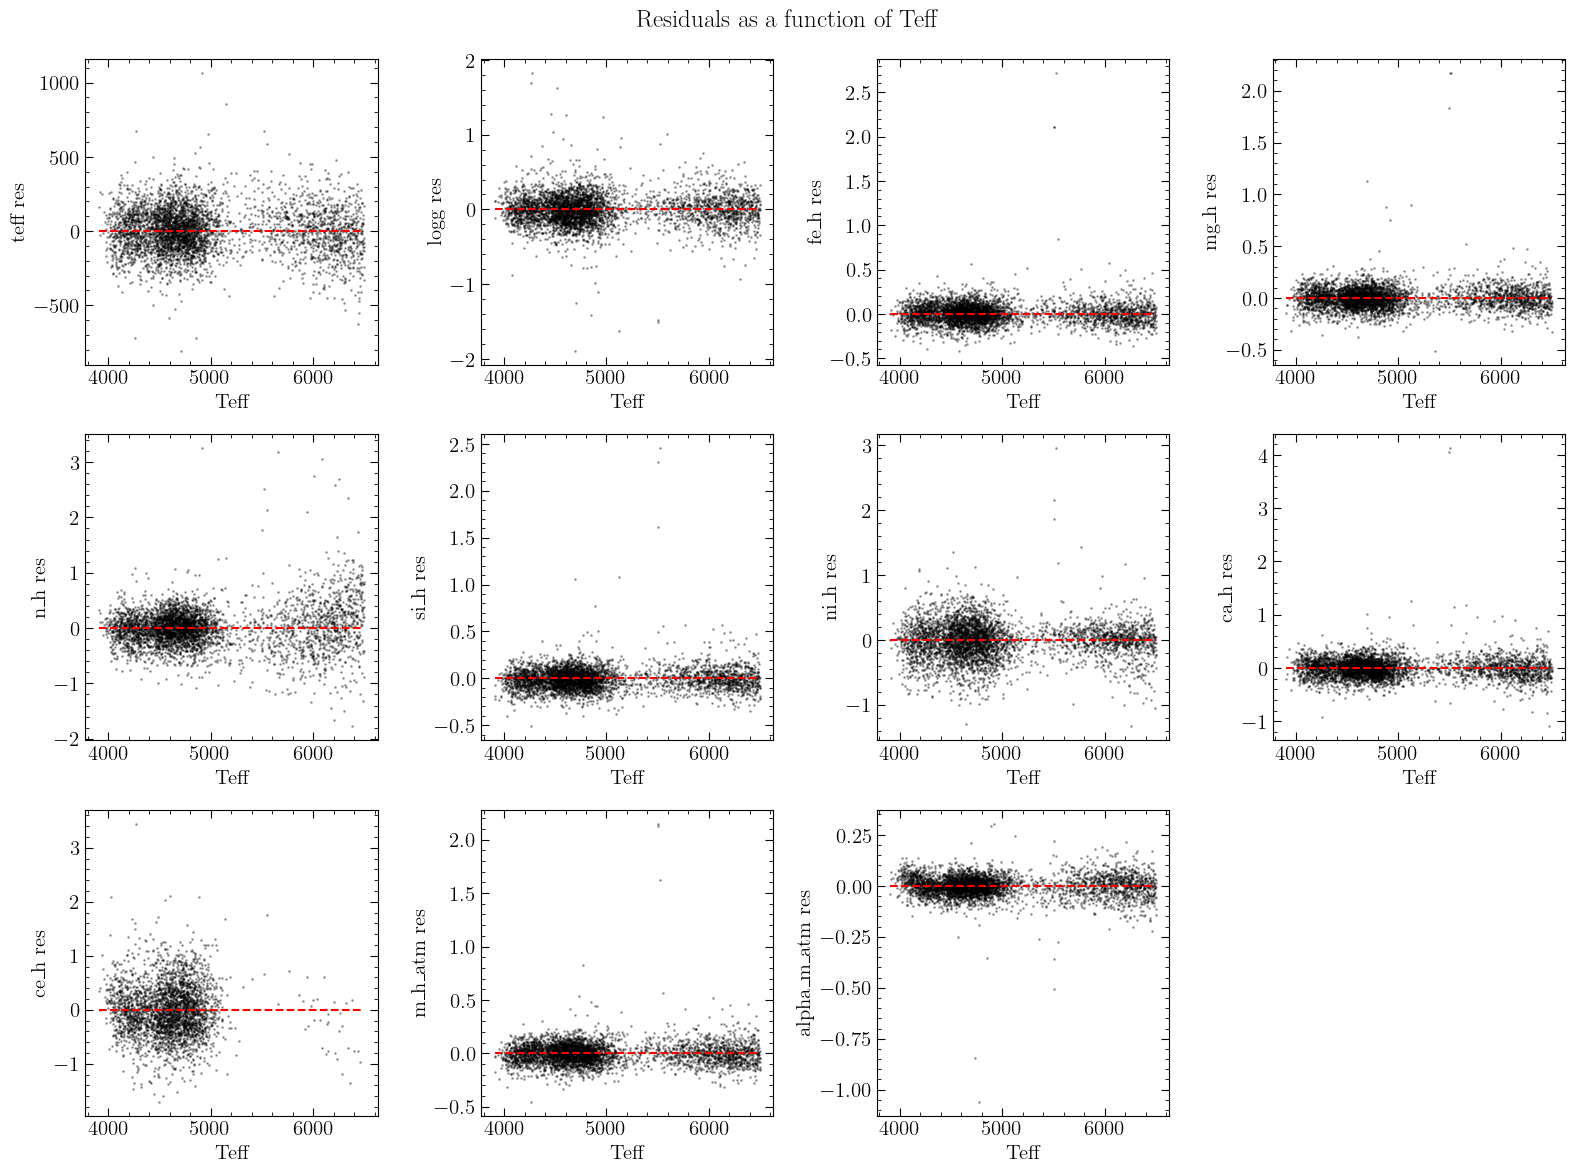

In [13]:
import matplotlib.pyplot as plt

features = [
    'teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 
    'ni_h', 'ca_h', 'ce_h', 'm_h_atm', 'alpha_m_atm'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

teff_true = test_results_all['teff_true']
teff_min, teff_max = teff_true.min(), teff_true.max()

for i in range(len(axes)):
    if i < len(features):
        feature = features[i]
        res_col = f'{feature}_residual'
        
        axes[i].scatter(teff_true, test_results_all[res_col], s=1, color='black', alpha=0.3)
        axes[i].plot([teff_min, teff_max], [0, 0], color='red', linestyle='--')
        
        axes[i].set_ylabel(f"{feature} res")
        axes[i].set_xlabel("Teff")
    else:
        fig.delaxes(axes[i]) 

plt.suptitle("Residuals as a function of Teff")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'SNR')

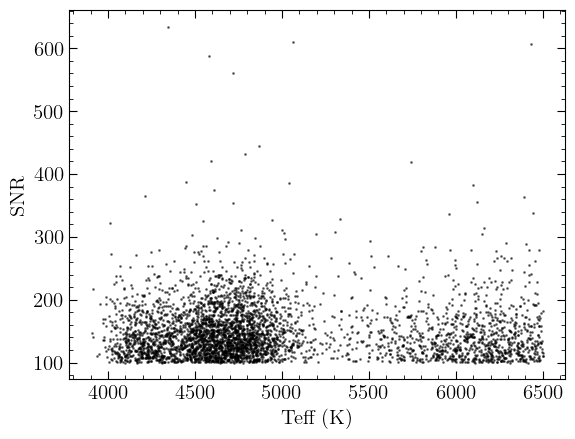

In [19]:
plt.scatter(test_results_all['teff_true'], test_results_all['rvs_spec_sig_to_noise'], s = 1, alpha = 0.5, color = 'black')
plt.xlabel("Teff (K)")
plt.ylabel("SNR")